<Axes: xlabel='Current density (A/cm$^2$)', ylabel='Cell voltage (V)'>

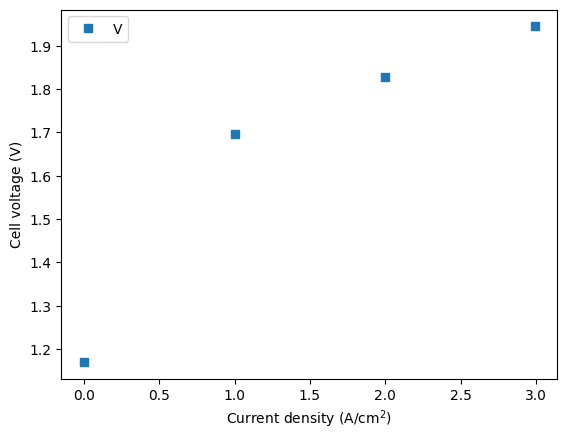

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dataclasses import dataclass, field
import marapendi as mrpd

exp_data = pd.read_csv(f'../data/tricker_et_al_2023/tricker_et_al_2023_fig1d.csv',sep=';',decimal=',')
exp_data_full = pd.read_csv(f'../data/tricker_et_al_2023/tricker_et_al_2023_figS4_IrO2.csv',sep=';',decimal=',')
exp_data.plot(x='i', y='V', marker='s', linewidth=0, 
              ylabel='Cell voltage (V)', xlabel='Current density (A/cm$^2$)')



In [25]:
exp_data

,i,Erev,Ohmic,Act_ca,Act_an,Mass_ca,V
0,0.000000,1.1695,1.169500,1.169500,1.169500,1.169500,1.169500
1,1.000885,1.1695,1.222481,1.317934,1.639108,1.687617,1.696223
2,1.996572,1.1695,1.280899,1.388088,1.719432,1.807454,1.828968
3,2.993645,1.1695,1.338143,1.449242,1.788020,1.903033,1.944892


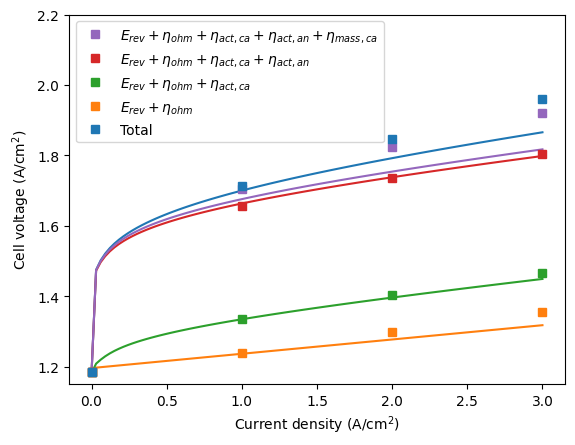

In [33]:
ec = mrpd.ElectrolyzerCell(
    cell_area=5e-4,  # Nominal value from Tricker et al. (2023)
    cell_number=1.,
    electrical_resistance=28e-7,
    electrolyte_saturation_exponent=1,
    ca=mrpd.ElectrolyzerCellSide(
        cl=mrpd.PtCCatalystLayer(
            thickness=12e-6,
            ionomer_to_carbon_ratio=0.5, # Nominal value from Tricker et al. (2023)
            carbon_agglomerate_radius=12.5e-9,
            platinum_loading=0.3e-2,     # Nominal value from Tricker et al. (2023)
            catalyst_platinum_weight_percent=0.468,
            ecsa=50e3,
            ionomer=mrpd.PAPIonomer(),
            reaction=mrpd.ElectrochemicalReaction(reference_exchange_current_density=40e1/50e3/0.3e-2,
                                                  activation_energy=50e6, 
                                                  reaction_order=0, 
                                                  reference_activity=1., 
                                                  number_of_electrons=2,
                                                  reference_temperature=353.15,charge_transfer_coeff=0.5),
            two_phase_transport_model=mrpd.DarcyTransportModel(0.4),
            absolute_permeability=1.3e-13,
            contact_angle=85,
        ),
        gdl=mrpd.PorousLayer( #AvCarb MGL370 compressed at 20% (value given by Tricker et al.)
            thickness=370e-6 * 0.8,  
            porosity=0.78 * 0.8, 
            two_phase_transport_model=mrpd.DarcyTransportModel(0.4),
            absolute_permeability=1e-12,
            contact_angle=45,
        )
    ),
    an = mrpd.ElectrolyzerCellSide(
        cl=mrpd.PorousTransferLayer( #Currento 10FP3 SS mesh
            thickness=280e-6, # 11 mil according to Tricker et al. (2023)
            porosity=0.71, 
            ionomer_to_catalyst_ratio=0.2, # Nominal value from Tricker et al. (2023)
            fiber_diameter=20e-6,
            catalyst_density=11700., # IrO2
            catalyst_loading=0.8e-2, # kg/m2s
            ecsa=1/(0.8e-2),
            absolute_permeability=1e-11,
            contact_angle=45,
            reaction=mrpd.ElectrochemicalReaction(reference_exchange_current_density=.2e-3, #A/m2IrO2
                                                  activation_energy=50e6, 
                                                  reaction_order=0, 
                                                  reference_activity=1., 
                                                  number_of_electrons=2., 
                                                  reference_temperature=353.15,charge_transfer_coeff=0.82),
            ionomer=mrpd.PAPIonomer(),
            two_phase_transport_model=mrpd.DarcyTransportModel(0.4)
        ),
        has_mpl=False, 
        has_gdl=False, 
    ),
    membrane=mrpd.PAP85(dry_thickness=30e-6) # Nominal value from Tricker et al. (2023)   
)

cathode_conditions = mrpd.OperatingConditions(
        inlet_temperature = 353.15, # Nominal value from Tricker et al. (2023)
        inlet_liquid_flow_rate=200e-6/60., # 200 mL/min
        inlet_liquid=mrpd.KOH_1M, # Nominal value from Tricker et al. (2023)
        dry_h2_mole_fraction=1, 
        dry_o2_mole_fraction=0,
        outlet_pressure=1.0e5,    # Nominal value from Tricker et al. (2023)
    )
anode_conditions = mrpd.OperatingConditions(
        inlet_temperature = 353.15, # Nominal value from Tricker et al. (2023)
        inlet_liquid_flow_rate=200e-6/60., # 200 mL/min
        inlet_liquid=mrpd.KOH_1M, # Nominal value from Tricker et al. (2023)
        dry_h2_mole_fraction=0, 
        dry_o2_mole_fraction=1,
        outlet_pressure=1.0e5,    # Nominal value from Tricker et al. (2023)
    )

ec.set_conditions(stack_temperature=353.15, current_density=1e4*np.linspace(0,3,100), cathode_conditions=cathode_conditions, anode_conditions=anode_conditions)
ec.calculate_bubble_transport()
ec.ca.cl.ionomer_water_content=12
ec.an.cl.ionomer_water_content=12
eta_act_ca = ec.ca.cl.activation_overpotential(ec.current_density, 1.)
eta_act_an = ec.an.cl.activation_overpotential(ec.current_density, 1.)
eta_mass_an = ec.an.cl.activation_overpotential(ec.current_density / (1-ec.an.cl.non_wetting_saturation)**ec.electrolyte_saturation_exponent, 1.) - eta_act_an
eta_mass_ca = ec.ca.cl.activation_overpotential(ec.current_density / (1-ec.ca.cl.non_wetting_saturation)**ec.electrolyte_saturation_exponent, 1.) - eta_act_ca
plt.plot(np.linspace(0,3,100), ec.cell_voltage(), 'C0')
plt.plot(np.linspace(0,3,100), ec.reversible_cell_voltage() + ec.high_frequency_resistance() *ec.current_density, 'C1')
plt.plot(np.linspace(0,3,100), ec.reversible_cell_voltage() + ec.high_frequency_resistance() *ec.current_density+ eta_act_ca, 'C2')
plt.plot(np.linspace(0,3,100), ec.reversible_cell_voltage() + ec.high_frequency_resistance() *ec.current_density+ eta_act_ca + eta_act_an, 'C3')
plt.plot(np.linspace(0,3,100), ec.reversible_cell_voltage() + ec.high_frequency_resistance() *ec.current_density+ eta_act_ca + eta_act_an + eta_mass_ca, 'C4')


plt.plot(exp_data["i"].values, exp_data["Mass_ca"].values+0.016, 'C4s', label='$E_{rev}+\eta_{ohm} +\eta_{act,ca}+\eta_{act,an} + \eta_{mass,ca}$')
plt.plot(exp_data["i"].values, exp_data["Act_an"].values+0.016, 'C3s', label='$E_{rev}+\eta_{ohm} +\eta_{act,ca}+\eta_{act,an}$')
plt.plot(exp_data["i"].values, exp_data["Act_ca"].values+0.016, 'C2s', label='$E_{rev}+\eta_{ohm} +\eta_{act,ca}$')
plt.plot(exp_data["i"].values, exp_data["Ohmic"].values+0.016, 'C1s', label='$E_{rev}+\eta_{ohm}$')
plt.plot(exp_data["i"].values, exp_data["V"].values+0.016, 'C0s', label='Total')

plt.legend()
plt.xlabel('Current density (A/cm$^2$)')
plt.ylabel('Cell voltage (A/cm$^2$)')
plt.ylim([1.15,2.2])
plt.savefig('./tricker_comparison.png', dpi=300)



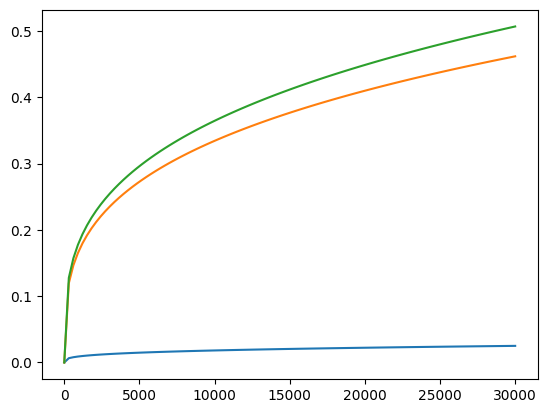

In [27]:

plt.plot(ec.current_density, ec.ca.gdl.non_wetting_saturation)
plt.plot(ec.current_density, ec.ca.cl.non_wetting_saturation)
plt.plot(ec.current_density, 0.023 * ec.current_density ** 0.3)

In [28]:
Q_g = 200e-6/60 
c_g = 1e5/353.15/8.3145
30000 / 4 / 96485 * 5e-4 / (Q_g * c_g)

0.3423639824195471